# 1.Import necessary libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# 2. Read the data

In [174]:
data = pd.read_excel(r"C:/Users/aksta/Desktop/python lessons/Baku_House_Price_Prediction.xlsx")

data.head()

,ID,location,rooms,square,price_per_sqm,which_floor,total_floors,is_top_floor,new_building,has_repair,has_bill_of_sale,has_mortgage,price
0,0,Azadlıq Prospekti m.,3,140.0000,2029,5,12,0,Yes,Yes,Yes,Yes,284000
1,1,Şah İsmayıl Xətai m.,3,135.0000,2630,19,20,0,Yes,Yes,Yes,Yes,355000
2,2,Səbail r.,4,210.0000,3595,7,18,0,Yes,Yes,Yes,Yes,755000
3,3,Elmlər Akademiyası m.,3,86.0000,2849,8,10,0,Yes,Yes,Yes,Yes,245000
4,4,Elmlər Akademiyası m.,4,174.0000,2011,12,15,0,Yes,Yes,Yes,Yes,350000


# 3. Descriptive Statistics


In [175]:
data.describe(include='all')

,ID,location,rooms,square,price_per_sqm,which_floor,total_floors,is_top_floor,new_building,has_repair,has_bill_of_sale,has_mortgage,price
count,39302.0000,39302,39302.0000,39302.0000,39302.0000,39302.0000,39302.0000,39302.0000,39302,39302,39302,39302,39302.0000
unique,NaN,111,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2,2,NaN
top,NaN,İnşaatçılar m.,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Yes,Yes,No,NaN
freq,NaN,2834,NaN,NaN,NaN,NaN,NaN,NaN,29708,32975,30194,26020,NaN
mean,19650.5000,NaN,2.8136,106.0393,2170.8071,8.1980,13.8584,0.0000,NaN,NaN,NaN,NaN,232232.3082
std,11345.6545,NaN,0.9149,59.8565,680.8094,4.9622,5.4108,0.0000,NaN,NaN,NaN,NaN,182775.4091
min,0.0000,NaN,1.0000,12.0000,348.0000,1.0000,1.0000,0.0000,NaN,NaN,NaN,NaN,9600.0000
25%,9825.2500,NaN,2.0000,65.0000,1786.0000,4.0000,9.0000,0.0000,NaN,NaN,NaN,NaN,135000.0000
50%,19650.5000,NaN,3.0000,94.0000,2092.0000,7.0000,16.0000,0.0000,NaN,NaN,NaN,NaN,187000.0000
75%,29475.7500,NaN,3.0000,130.0000,2479.7500,12.0000,18.0000,0.0000,NaN,NaN,NaN,NaN,277000.0000


# 4. Check Missing values

In [176]:
data.isnull().sum()

ID                  0
location            0
rooms               0
square              0
price_per_sqm       0
which_floor         0
total_floors        0
is_top_floor        0
new_building        0
has_repair          0
has_bill_of_sale    0
has_mortgage        0
price               0
dtype: int64

# 5. Create Additional features

- Avg_square_by_location
- Max_floors_by_location

In [177]:
data["Avg_square_by_location"] = data.groupby("location")["square"].transform("mean")
data["Max_floors_by_location"]  = data.groupby("location")["total_floors"].transform("max")

data

,ID,location,rooms,square,price_per_sqm,which_floor,total_floors,is_top_floor,new_building,has_repair,has_bill_of_sale,has_mortgage,price,Avg_square_by_location,Max_floors_by_location
0,0,Azadlıq Prospekti m.,3,140.0000,2029,5,12,0,Yes,Yes,Yes,Yes,284000,95.5852,21
1,1,Şah İsmayıl Xətai m.,3,135.0000,2630,19,20,0,Yes,Yes,Yes,Yes,355000,132.1632,33
2,2,Səbail r.,4,210.0000,3595,7,18,0,Yes,Yes,Yes,Yes,755000,128.2058,33
3,3,Elmlər Akademiyası m.,3,86.0000,2849,8,10,0,Yes,Yes,Yes,Yes,245000,130.0858,27
4,4,Elmlər Akademiyası m.,4,174.0000,2011,12,15,0,Yes,Yes,Yes,Yes,350000,130.0858,27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39297,39297,9-cu mikrorayon q.,2,45.0000,1900,9,9,0,No,No,Yes,No,85500,80.8552,23
39298,39298,Memar Əcəmi m.,2,48.0000,2135,3,5,0,No,No,Yes,No,102500,78.5148,22
39299,39299,İnşaatçılar m.,3,65.0000,2208,3,5,0,No,No,Yes,No,143500,100.3962,27
39300,39300,Elmlər Akademiyası m.,4,90.0000,1911,3,5,0,No,No,Yes,No,172000,130.0858,27


# 6. Drop Unnecessary columns



In [178]:
data.drop(['ID', 'location', 'is_top_floor'], axis=1, inplace=True)

data


,rooms,square,price_per_sqm,which_floor,total_floors,new_building,has_repair,has_bill_of_sale,has_mortgage,price,Avg_square_by_location,Max_floors_by_location
0,3,140.0000,2029,5,12,Yes,Yes,Yes,Yes,284000,95.5852,21
1,3,135.0000,2630,19,20,Yes,Yes,Yes,Yes,355000,132.1632,33
2,4,210.0000,3595,7,18,Yes,Yes,Yes,Yes,755000,128.2058,33
3,3,86.0000,2849,8,10,Yes,Yes,Yes,Yes,245000,130.0858,27
4,4,174.0000,2011,12,15,Yes,Yes,Yes,Yes,350000,130.0858,27
...,...,...,...,...,...,...,...,...,...,...,...,...
39297,2,45.0000,1900,9,9,No,No,Yes,No,85500,80.8552,23
39298,2,48.0000,2135,3,5,No,No,Yes,No,102500,78.5148,22
39299,3,65.0000,2208,3,5,No,No,Yes,No,143500,100.3962,27
39300,4,90.0000,1911,3,5,No,No,Yes,No,172000,130.0858,27


# 7. Check the Linearity assumptions

Text(0.5, 1.0, 'MaxFloorsbyLoc and Price')

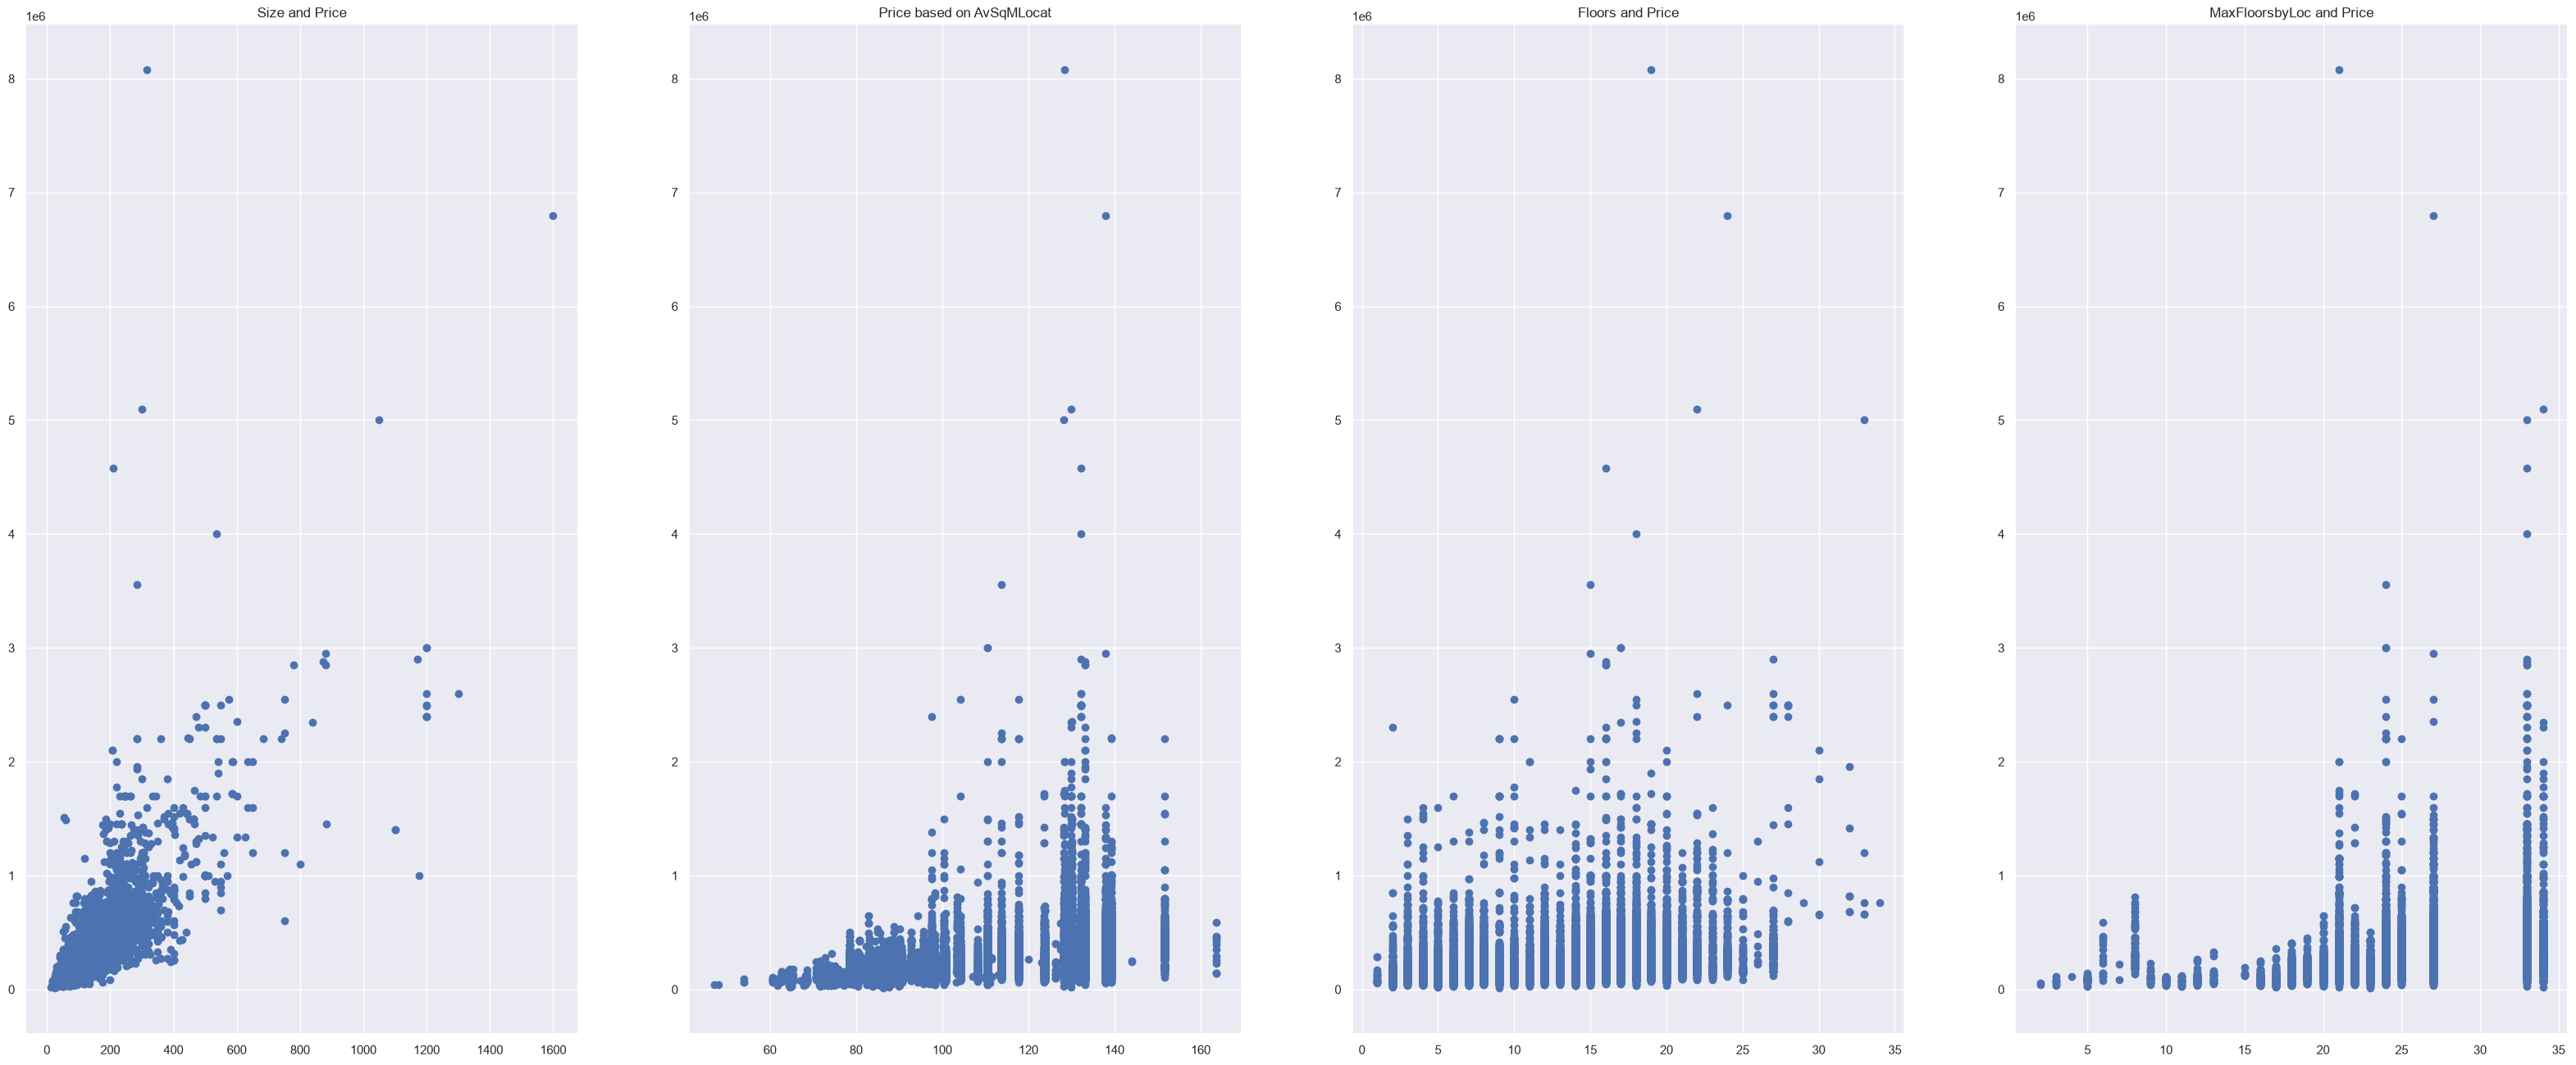

In [179]:
fig, (ax1,ax3,ax4,ax5) = plt.subplots(1,4, figsize=(40,16))

ax1.scatter(data['square'],data['price'])
ax1.set_title('Size and Price')


ax3.scatter(data['Avg_square_by_location'],data['price'])
ax3.set_title('Price based on AvSqMLocat')

ax4.scatter(data['total_floors'],data['price'])
ax4.set_title('Floors and Price')

ax5.scatter(data['Max_floors_by_location'],data['price'])
ax5.set_title('MaxFloorsbyLoc and Price')


# 8. Declare the inputs and the targets

In [180]:
targets = data['price']

inputs = data.drop(['price'],axis=1)

# 9. Train Test Split

In [182]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(inputs, targets, test_size=0.3, random_state=1)

In [128]:
print('X_train shape', X_train.shape)
print('X_test shape', X_test.shape)
print('y_train shape', y_train.shape)
print('y_test shape', y_test.shape)

X_train shape (27511, 11)
X_test shape (11791, 11)
y_train shape (27511,)
y_test shape (11791,)


# 10. Explore outliers and treat with IQR

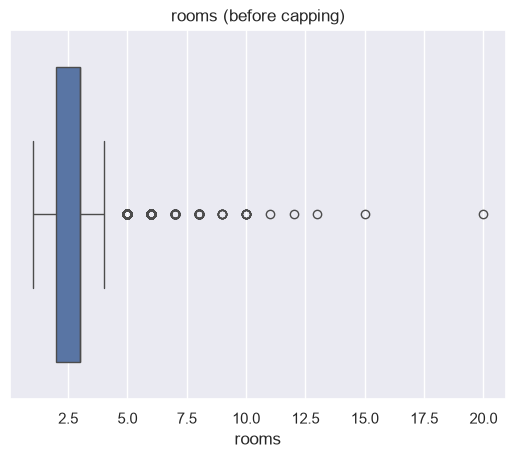

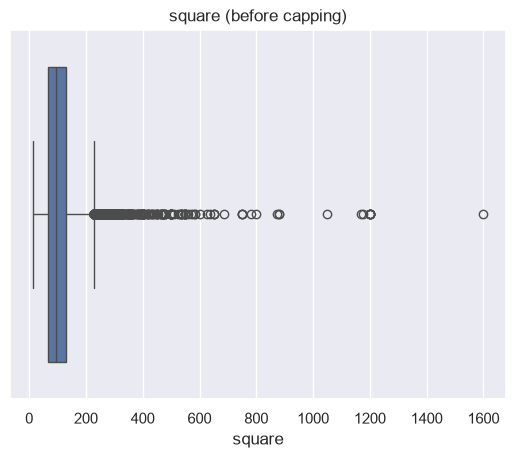

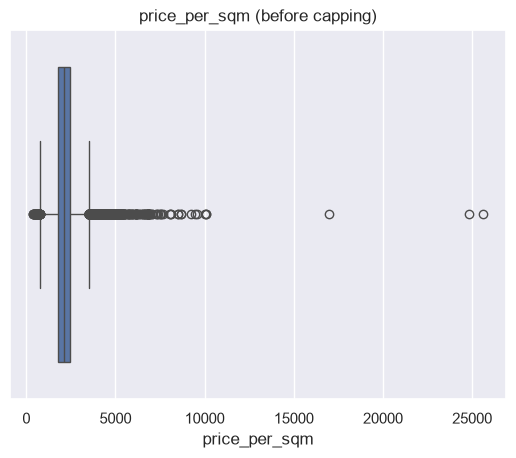

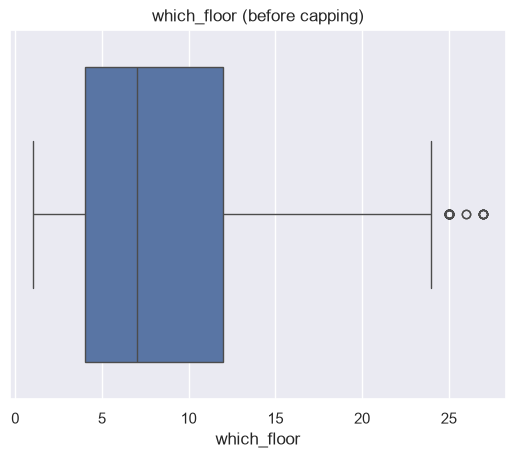

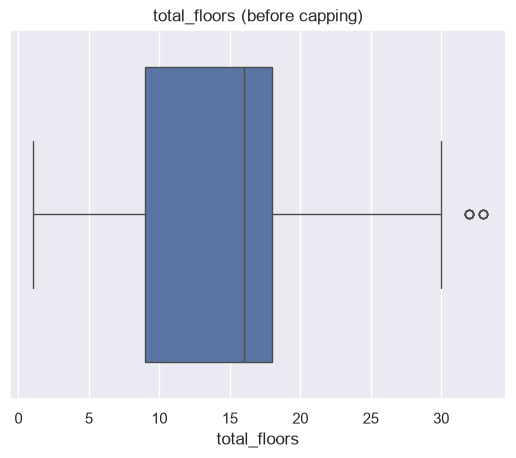

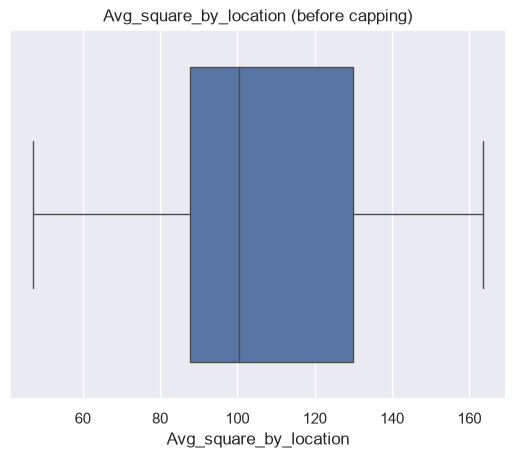

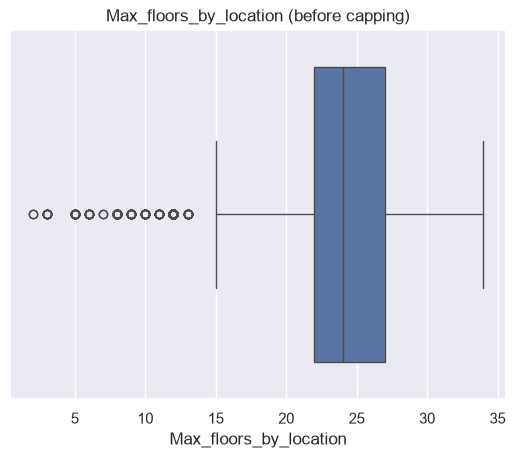

In [183]:
# Explore outliers first
numeric_cols = X_train.select_dtypes(include='number').columns

for col in numeric_cols:
    sns.boxplot(data=X_train, x=X_train[col])
    plt.title(f'{col} (before capping)')
    plt.show()

In [184]:

# Compute IQR bounds from X_train only
q1 = X_train.quantile(0.25, numeric_only=True)
q3 = X_train.quantile(0.75, numeric_only=True)
IQR = q3 - q1

Lower = q1 - 1.5 * IQR
Upper = q3 + 1.5 * IQR



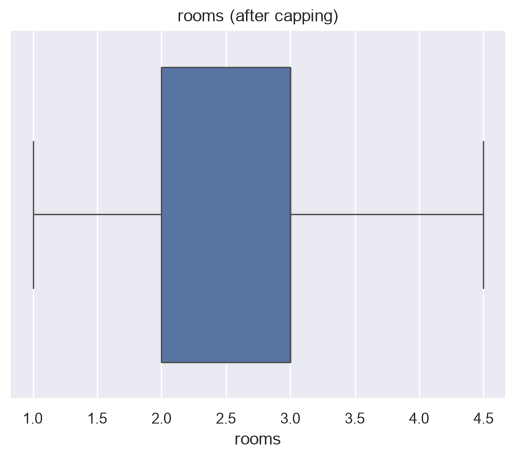

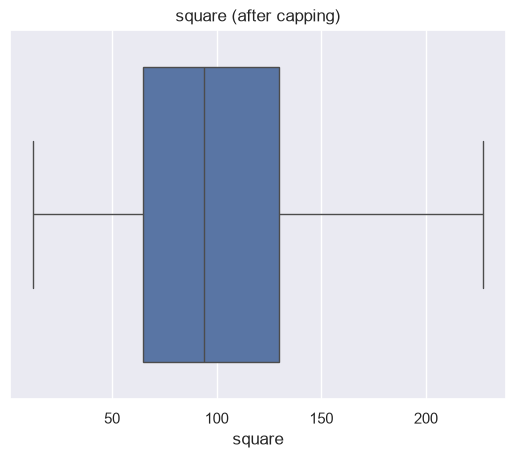

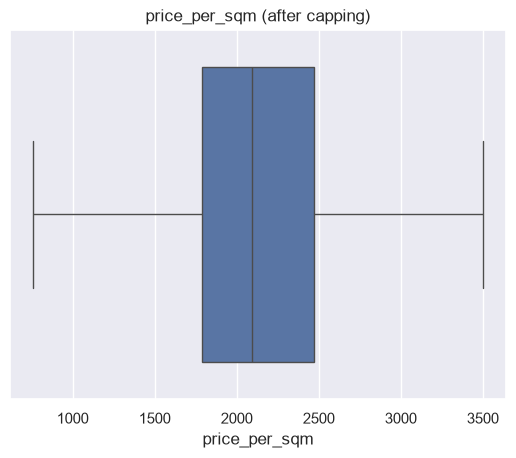

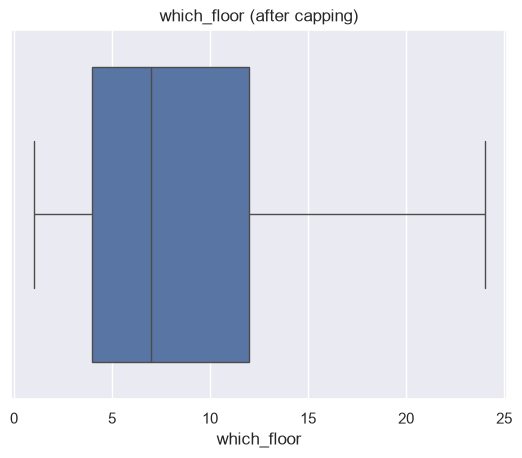

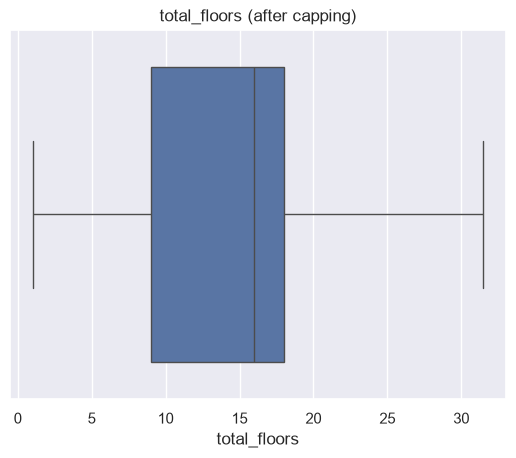

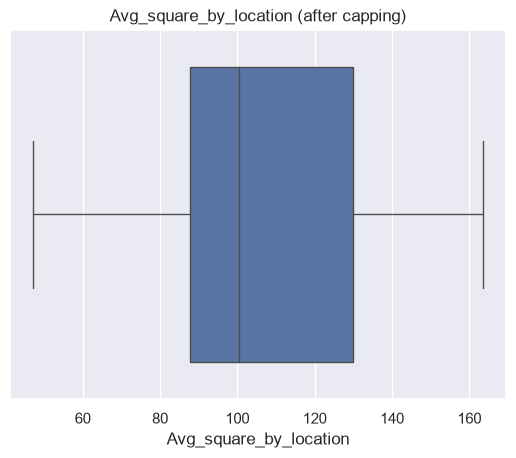

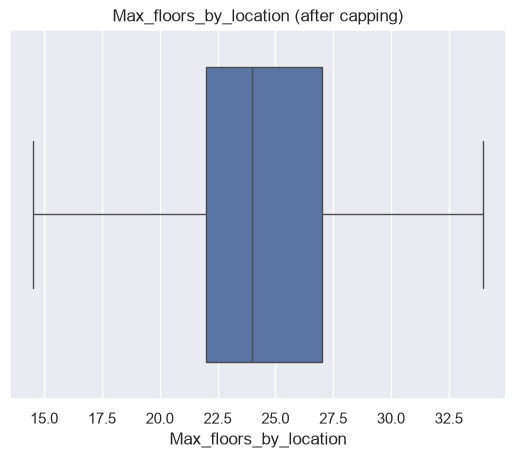

In [185]:
# Treat (cap) the outliers — apply to BOTH X_train and X_test
for col in numeric_cols:
    for df in (X_train, X_test):
        df[col] = np.where(df[col] > Upper[col], Upper[col], df[col])
        df[col] = np.where(df[col] < Lower[col], Lower[col], df[col])
    sns.boxplot(data=X_train, x=X_train[col])
    plt.title(f'{col} (after capping)')
    plt.show()

# 11. Check Distribution of data with KStest

In [186]:
from scipy import stats

for i in X_train.columns:
    
    if X_train[i].dtype in ['int64', 'float64']:
        
        kstest_statistic, kstest_p_value = stats.kstest(X_train[i], 'norm')
        
        # 'norm' inside indicates that the test is comparing the distribution of the data against a normal distribution
        
        print(f'Column: {i}')
        print(f'p-value: {kstest_p_value}')
        
        if kstest_p_value > 0.05:
            print('Data looks normally distributed')
            print()
        else:
            print('Data does not look normally distributed')
            print()

Column: rooms
p-value: 0.0
Data does not look normally distributed

Column: square
p-value: 0.0
Data does not look normally distributed

Column: price_per_sqm
p-value: 0.0
Data does not look normally distributed

Column: which_floor
p-value: 0.0
Data does not look normally distributed

Column: total_floors
p-value: 0.0
Data does not look normally distributed

Column: Avg_square_by_location
p-value: 0.0
Data does not look normally distributed

Column: Max_floors_by_location
p-value: 0.0
Data does not look normally distributed



# 12. Check correlation between independent features

In [187]:
X_train.corr(numeric_only=True, method='spearman')

,rooms,square,price_per_sqm,which_floor,total_floors,Avg_square_by_location,Max_floors_by_location
rooms,1.0000,0.7821,-0.0952,0.1123,0.1251,0.2149,0.1611
square,0.7821,1.0000,-0.0675,0.2800,0.3916,0.3862,0.3062
price_per_sqm,-0.0952,-0.0675,1.0000,0.0088,0.0712,0.5049,0.3752
which_floor,0.1123,0.2800,0.0088,1.0000,0.6154,0.1289,0.1692
total_floors,0.1251,0.3916,0.0712,0.6154,1.0000,0.1997,0.2631
Avg_square_by_location,0.2149,0.3862,0.5049,0.1289,0.1997,1.0000,0.7914
Max_floors_by_location,0.1611,0.3062,0.3752,0.1692,0.2631,0.7914,1.0000


In [188]:
def intercorrelation(data, threshold=0.7):
    corr = data.corr(numeric_only=True,method="spearman")

    upper = np.triu(np.ones(corr.shape, dtype=bool),k=1)
    print(upper)
    
    rows, cols = np.where(upper & (corr.abs().values >= threshold))
  
    return pd.DataFrame({
        "Variable 1": corr.index[rows],
        "Variable 2": corr.columns[cols],
        "Correlation": corr.values[rows, cols]
    }).reset_index(drop=True)

In [189]:
intercorrelated_result = intercorrelation(X_train)

intercorrelated_result

[[False  True  True  True  True  True  True]
 [False False  True  True  True  True  True]
 [False False False  True  True  True  True]
 [False False False False  True  True  True]
 [False False False False False  True  True]
 [False False False False False False  True]
 [False False False False False False False]]


,Variable 1,Variable 2,Correlation
0,rooms,square,0.7821
1,Avg_square_by_location,Max_floors_by_location,0.7914


In [191]:
numeric_columns = X_train.select_dtypes(include="number").columns

categorical_columns = X_train.select_dtypes(include=["object", "category"]).columns

C:\Users\aksta\AppData\Local\Temp\ipykernel_5904\2067246784.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X_train.select_dtypes(include=["object", "category"]).columns


In [192]:
numeric_columns

Index(['rooms', 'square', 'price_per_sqm', 'which_floor', 'total_floors',
       'Avg_square_by_location', 'Max_floors_by_location'],
      dtype='str')

In [193]:
categorical_columns

Index(['new_building', 'has_repair', 'has_bill_of_sale', 'has_mortgage'], dtype='str')

# 13. Multicollinearity between independent features - VIF test

- VIF between 1-6 (for this example)

In [201]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


def calculate_vif(data, variables):
    vif_data = data[variables]
    vif_values = [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]
    vif_result = pd.DataFrame({'VIF': vif_values, 'Features': variables})
    return vif_result


vif_result = calculate_vif(X_train, [#'rooms',
                                     'square',
                                     'price_per_sqm',
                                     'which_floor',
                                     #'total_floors',
                                     #'Avg_square_by_location',
                                    #'Max_floors_by_location'
                                    ])
                                     
vif_result
                                     


,VIF,Features
0,5.3061,square
1,5.2100,price_per_sqm
2,3.7388,which_floor


# 15. Create dummy variables (Conversion categorical variables into numeric ones)

In [202]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    drop='first', 
    handle_unknown='ignore', 
    sparse_output=False,
    dtype=int
)

X_train_encoded = encoder.fit_transform(X_train[categorical_columns])
X_test_encoded = encoder.transform(X_test[categorical_columns])

In [203]:
X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoder.get_feature_names_out(categorical_columns),
    index=X_train.index
)

X_train_encoded

,new_building_Yes,has_repair_Yes,has_bill_of_sale_Yes,has_mortgage_Yes
22261,1,1,1,0
12717,1,1,0,0
5632,1,1,1,1
7405,1,1,1,1
33326,0,1,1,0
...,...,...,...,...
7813,1,1,1,1
32511,0,1,1,1
5192,1,1,1,1
12172,1,1,0,0


In [204]:
X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoder.get_feature_names_out(categorical_columns),
    index=X_test.index
)

X_test_encoded

,new_building_Yes,has_repair_Yes,has_bill_of_sale_Yes,has_mortgage_Yes
17700,1,1,1,0
9498,1,1,0,0
22059,1,1,1,0
2990,1,1,1,1
36045,0,1,1,0
...,...,...,...,...
32764,0,1,1,0
23921,1,0,1,1
29361,1,0,1,0
24736,1,0,1,1


In [205]:
X_train_num = X_train[['square', 'which_floor', 'price_per_sqm']].copy()
X_test_num = X_test[['square', 'which_floor', 'price_per_sqm']].copy()

display(X_train_num)
display(X_test_num)

,square,which_floor,price_per_sqm
22261,137.0000,9.0000,2007.0000
12717,120.0000,2.0000,2250.0000
5632,146.0000,17.0000,2253.0000
7405,140.0000,8.0000,1207.0000
33326,100.0000,1.0000,1650.0000
...,...,...,...
7813,80.7000,8.0000,2131.0000
32511,60.0000,3.0000,2250.0000
5192,115.5000,10.0000,2208.0000
12172,42.0000,1.0000,1262.0000


,square,which_floor,price_per_sqm
17700,42.0000,12.0000,1548.0000
9498,40.0000,2.0000,925.0000
22059,97.0000,17.0000,1701.0000
2990,140.0000,3.0000,1821.0000
36045,55.0000,1.0000,2255.0000
...,...,...,...
32764,40.0000,8.0000,1922.0000
23921,227.5000,12.0000,1377.0000
29361,198.0000,3.0000,3146.0000
24736,67.0000,19.0000,1754.0000


In [206]:
X_train_final = pd.concat([X_train_num, X_train_encoded],axis=1)
X_test_final = pd.concat([X_test_num, X_test_encoded],axis=1)

display(X_train_final)
display(X_test_final)

,square,which_floor,price_per_sqm,new_building_Yes,has_repair_Yes,has_bill_of_sale_Yes,has_mortgage_Yes
22261,137.0000,9.0000,2007.0000,1,1,1,0
12717,120.0000,2.0000,2250.0000,1,1,0,0
5632,146.0000,17.0000,2253.0000,1,1,1,1
7405,140.0000,8.0000,1207.0000,1,1,1,1
33326,100.0000,1.0000,1650.0000,0,1,1,0
...,...,...,...,...,...,...,...
7813,80.7000,8.0000,2131.0000,1,1,1,1
32511,60.0000,3.0000,2250.0000,0,1,1,1
5192,115.5000,10.0000,2208.0000,1,1,1,1
12172,42.0000,1.0000,1262.0000,1,1,0,0


,square,which_floor,price_per_sqm,new_building_Yes,has_repair_Yes,has_bill_of_sale_Yes,has_mortgage_Yes
17700,42.0000,12.0000,1548.0000,1,1,1,0
9498,40.0000,2.0000,925.0000,1,1,0,0
22059,97.0000,17.0000,1701.0000,1,1,1,0
2990,140.0000,3.0000,1821.0000,1,1,1,1
36045,55.0000,1.0000,2255.0000,0,1,1,0
...,...,...,...,...,...,...,...
32764,40.0000,8.0000,1922.0000,0,1,1,0
23921,227.5000,12.0000,1377.0000,1,0,1,1
29361,198.0000,3.0000,3146.0000,1,0,1,0
24736,67.0000,19.0000,1754.0000,1,0,1,1


# 16. Scale the data

In [207]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
scaler.fit(X_train_final)

# Transform train and test
X_train_scaled = scaler.transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

# Convert back to DataFrames
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train_final.columns,
    index=X_train_final.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test_final.columns,
    index=X_test_final.index
)

display(X_train_scaled)
display(X_test_scaled)

,square,which_floor,price_per_sqm,new_building_Yes,has_repair_Yes,has_bill_of_sale_Yes,has_mortgage_Yes
22261,0.7052,0.1607,-0.2549,0.5716,0.4374,0.5480,-0.7135
12717,0.3449,-1.2485,0.1919,0.5716,0.4374,-1.8248,-0.7135
5632,0.8959,1.7712,0.1974,0.5716,0.4374,0.5480,1.4015
7405,0.7688,-0.0406,-1.7259,0.5716,0.4374,0.5480,1.4015
33326,-0.0789,-1.4498,-0.9114,-1.7495,0.4374,0.5480,-0.7135
...,...,...,...,...,...,...,...
7813,-0.4879,-0.0406,-0.0269,0.5716,0.4374,0.5480,1.4015
32511,-0.9266,-1.0472,0.1919,-1.7495,0.4374,0.5480,1.4015
5192,0.2496,0.3620,0.1146,0.5716,0.4374,0.5480,1.4015
12172,-1.3080,-1.4498,-1.6248,0.5716,0.4374,-1.8248,-0.7135


,square,which_floor,price_per_sqm,new_building_Yes,has_repair_Yes,has_bill_of_sale_Yes,has_mortgage_Yes
17700,-1.3080,0.7646,-1.0989,0.5716,0.4374,0.5480,-0.7135
9498,-1.3504,-1.2485,-2.2444,0.5716,0.4374,-1.8248,-0.7135
22059,-0.1425,1.7712,-0.8176,0.5716,0.4374,0.5480,-0.7135
2990,0.7688,-1.0472,-0.5969,0.5716,0.4374,0.5480,1.4015
36045,-1.0325,-1.4498,0.2011,-1.7495,0.4374,0.5480,-0.7135
...,...,...,...,...,...,...,...
32764,-1.3504,-0.0406,-0.4112,-1.7495,0.4374,0.5480,-0.7135
23921,2.6231,0.7646,-1.4133,0.5716,-2.2863,0.5480,1.4015
29361,1.9979,-1.0472,1.8393,0.5716,-2.2863,0.5480,-0.7135
24736,-0.7782,2.1738,-0.7201,0.5716,-2.2863,0.5480,1.4015


# 17. Create the Linear regression

In [208]:
reg = LinearRegression()

reg.fit(X_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[131167.33, 1200.98, 74771.25,..., -604.6 , 3072.41, -2103.39]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['square','which_floor','price_per_sqm',...,'has_repair_Yes', 'has_bill_of_sale_Yes','has_mortgage_Yes']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.326e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


In [209]:
reg.coef_

array([131167.33010851,   1200.98133836,  74771.25402685,  -8128.78300091,
         -604.59530196,   3072.40962617,  -2103.39310511])

In [210]:
reg.intercept_

np.float64(232588.8653265967)

In [211]:
y_pred = reg.predict(X_test_scaled)
y_pred_train = reg.predict(X_train_scaled)

# 18. Evaluate the model

In [212]:
from sklearn import metrics

# Test metrics
mae_test = metrics.mean_absolute_error(y_test, y_pred)
mse_test = metrics.mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)
mape_test = metrics.mean_absolute_percentage_error(y_test, y_pred)
r2_test = metrics.r2_score(y_test, y_pred)

# Train metrics
mae_train = metrics.mean_absolute_error(y_train, y_pred_train)
mse_train = metrics.mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
mape_train = metrics.mean_absolute_percentage_error(y_train, y_pred_train)
r2_train = metrics.r2_score(y_train, y_pred_train)


# Adjusted R2
def adjusted_r2(r2, n, k):
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)


n_train = len(y_train)
n_test = len(y_test)
k = X_train.shape[1]

adj_r2_train = adjusted_r2(r2_train, n_train, k)
adj_r2_test = adjusted_r2(r2_test, n_test, k)


# Results summary
results_dict = {
    "Metric": ["MAE", "MSE", "RMSE", "MAPE", "R2", "Adjusted R2"],
    "Train": [
        mae_train,
        mse_train,
        rmse_train,
        mape_train,
        r2_train,
        adj_r2_train
    ],
    "Test": [
        mae_test,
        mse_test,
        rmse_test,
        mape_test,
        r2_test,
        adj_r2_test
    ]
}

results_df = pd.DataFrame(results_dict)

results_df

,Metric,Train,Test
0,MAE,37341.6529,36581.8320
1,MSE,12981323877.6501,8436592387.1294
2,RMSE,113935.6129,91850.9248
3,MAPE,0.1953,0.2004
4,R2,0.6303,0.7132
5,Adjusted R2,0.6302,0.7129


# 19. Univariate Analysis of each variables

In [213]:
results = []

for i in X_train_scaled.columns: 
    X_train_single_var = X_train_scaled[[i]]
    X_test_single_var = X_test_scaled[[i]]

    reg.fit(X_train_single_var, y_train)
    
    y_pred_train_single_var = reg.predict(X_train_single_var)

    train_r2 = metrics.r2_score(y_train, y_pred_train_single_var)

    y_pred_test_single_var = reg.predict(X_test_single_var)

    test_r2 = metrics.r2_score(y_test, y_pred_test_single_var)

    results.append({'Variable': i, 'Train R2': train_r2, 'Test R2': test_r2})

results_df = pd.DataFrame(results)

results_df_sorted = results_df.sort_values(by='Test R2', ascending=False)

results_df_sorted


,Variable,Train R2,Test R2
0,square,0.4705,0.5332
2,price_per_sqm,0.1600,0.1778
3,new_building_Yes,0.0655,0.0715
1,which_floor,0.0251,0.0252
4,has_repair_Yes,0.0135,0.0148
6,has_mortgage_Yes,0.0000,-0.0000
5,has_bill_of_sale_Yes,0.0003,-0.0001


# 20. Build model using selected variables and check model performance

In [215]:
X_train_uni = X_train_scaled[['square','price_per_sqm']]
X_test_uni = X_test_scaled[['square','price_per_sqm']]

In [216]:
reg = LinearRegression()
reg.fit(X_train_uni,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[128232.87, 74429.6 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['square','price_per_sqm']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.326e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [217]:
y_pred_uni = reg.predict(X_test_uni)
y_pred_train_uni = reg.predict(X_train_uni)

In [218]:
# Test metrics
mae_test = metrics.mean_absolute_error(y_test, y_pred_uni)
mse_test = metrics.mean_squared_error(y_test, y_pred_uni)
rmse_test = np.sqrt(mse_test)
r2_test = metrics.r2_score(y_test, y_pred_uni)
mape_test = metrics.mean_absolute_percentage_error(y_test, y_pred_uni)

# Train metrics
mae_train = metrics.mean_absolute_error(y_train, y_pred_train_uni)
mse_train = metrics.mean_squared_error(y_train, y_pred_train_uni)
rmse_train = np.sqrt(mse_train)
r2_train = metrics.r2_score(y_train, y_pred_train_uni)
mape_train = metrics.mean_absolute_percentage_error(y_train, y_pred_train_uni)


# Adjusted R2
def adjusted_r2(r2, n, k):
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)


n_train = len(y_train)
n_test = len(y_test)
k = X_train_uni.shape[1]

adj_r2_train = adjusted_r2(r2_train, n_train, k)
adj_r2_test = adjusted_r2(r2_test, n_test, k)


# Results summary
results_dict = {
    "Metric": ["MAE", "MSE", "RMSE", "MAPE", "R2", "Adjusted R2"],
    "Train": [
        mae_train,
        mse_train,
        rmse_train,
        mape_train,
        r2_train,
        adj_r2_train
    ],
    "Test": [
        mae_test,
        mse_test,
        rmse_test,
        mape_test,
        r2_test,
        adj_r2_test
    ]
}

results_df = pd.DataFrame(results_dict)

results_df 

,Metric,Train,Test
0,MAE,37879.5700,36992.1344
1,MSE,13053256942.3466,8476595818.2038
2,RMSE,114250.8509,92068.4301
3,MAPE,0.1969,0.2007
4,R2,0.6283,0.7118
5,Adjusted R2,0.6283,0.7118
